WRITE THE PYTHON CODE TO IMPLEMENT THE Q-LEARNING ALGORITHM.

Step 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Step 2: Define Environment

In [ ]:
n_states = 16
n_actions = 4   # Left, Right, Up, Down
goal_state = 15

Q_table = np.zeros((n_states, n_actions))

Step 3: Set Hyperparameters

In [ ]:
learning_rate = 0.8      # α
discount_factor = 0.95   # γ
exploration_prob = 0.2   # ε
episodes = 1000

Step 4: Define Transition Function

In [ ]:
def get_next_state(state, action):
    row, col = divmod(state, 4)

    if action == 0 and col > 0:        # Left
        col -= 1
    elif action == 1 and col < 3:      # Right
        col += 1
    elif action == 2 and row > 0:      # Up
        row -= 1
    elif action == 3 and row < 3:      # Down
        row += 1

    return row * 4 + col

Step 5: Train the Agent (Q-Learning Core)

In [ ]:
for episode in range(episodes):
    state = np.random.randint(0, n_states)

    while True:
        # Epsilon-greedy policy
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[state])

        next_state = get_next_state(state, action)

        reward = 1 if next_state == goal_state else 0

        # Q-learning update rule
        Q_table[state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[state, action]
        )

        if next_state == goal_state:
            break

        state = next_state

Step 6: Visualize Results

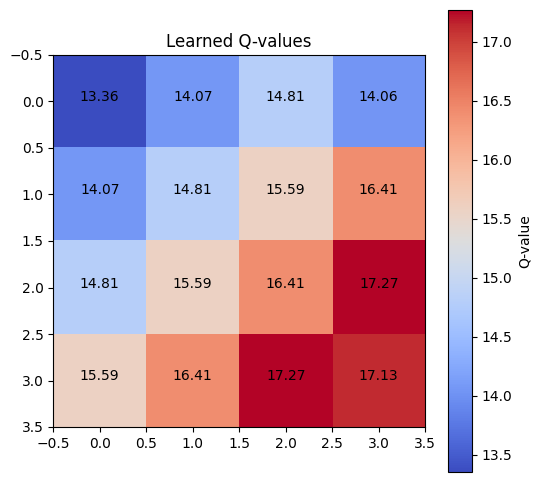

In [ ]:
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values')

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center')

plt.show()

Print Q-table

In [ ]:
print("Learned Q-table:")
print(Q_table)

Learned Q-table:
[[10.29613062 11.2091577   9.72509005 13.3559149 ]
 [10.33601735 12.44000745 11.10125496 14.06514623]
 [12.81438583 11.96036578 13.88132553 14.80640306]
 [14.05650998 11.44398403 11.14646973 11.22634196]
 [13.15348544 10.89653094 12.26475442 14.06608141]
 [10.70845479 14.80639826  5.69176116 10.28294357]
 [13.7176831  15.20045154 14.05697346 15.58568744]
 [14.00389226 11.26818691 13.25018179 16.40591226]
 [13.24562047 14.78913945 13.01691307 14.80640305]
 [13.06437345 13.6365319  13.56417542 15.58568742]
 [14.78942956 16.39446193 13.27848578 16.40598678]
 [15.52035877 15.06987874 14.72140538 17.26945977]
 [14.13037261 15.58568744 14.05559189 14.63544892]
 [14.52076584 16.40598678 14.79355599 15.51163991]
 [15.54232597 17.26945977 15.58534197 16.37608424]
 [14.85548032 17.12574712  8.55872541 13.2050636 ]]
